In [2]:
# Importer les bibliothèques necessaire
!pip install gdown
import gdown
import pandas as pd
import re
import gc
import os
import sys
import pandas as pd
import numpy as np
import tqdm
import seaborn as sns

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from scipy.stats import chi2_contingency
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [gdown]


In [2]:
np.random.seed(123)

In [3]:
data = pd.read_csv("Fraud Detection Dataset.csv")

In [4]:
data.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [5]:
data.nunique()

Transaction_ID                      50000
User_ID                              4000
Transaction_Amount                  44821
Transaction_Type                        5
Time_of_Transaction                    24
Device_Used                             4
Location                                8
Previous_Fraudulent_Transactions        5
Account_Age                           119
Number_of_Transactions_Last_24H        14
Payment_Method                          5
Fraudulent                              2
dtype: int64

Ce dataset comporte des informations sur les transactions de 4000 utilisateurs différents sur une période de 24h.

In [6]:
# Part de valeurs manquantes dans le dataset
data.isna().sum()/data['User_ID'].count()*100

Transaction_ID                      0.000000
User_ID                             0.000000
Transaction_Amount                  4.941176
Transaction_Type                    0.000000
Time_of_Transaction                 5.003922
Device_Used                         4.849020
Location                            4.994118
Previous_Fraudulent_Transactions    0.000000
Account_Age                         0.000000
Number_of_Transactions_Last_24H     0.000000
Payment_Method                      4.841176
Fraudulent                          0.000000
dtype: float64

Quelques mesures statistiques sur les différentes variables présentes :

In [7]:
data.describe()

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,51000.000000,48480.000000,48448.000000,51000.000000,51000.000000,51000.000000,51000.000000
mean,3005.110176,2996.249784,11.488400,1.995725,60.033902,7.495588,0.049216
std,1153.121107,5043.932555,6.922954,1.415150,34.384131,4.020080,0.216320
min,1000.000000,5.030000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2007.000000,1270.552500,5.000000,1.000000,30.000000,4.000000,0.000000
50%,2996.000000,2524.100000,12.000000,2.000000,60.000000,7.000000,0.000000
75%,4006.000000,3787.240000,17.000000,3.000000,90.000000,11.000000,0.000000
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


In [8]:
data['Fraudulent'].value_counts()/data['User_ID'].count()*100

Fraudulent
0    95.078431
1     4.921569
Name: count, dtype: float64

Le déséquilibre de classes est plutôt clair ici avec des transactions licites qui représentent 95,1% des données tandis que les transactions frauduleuses n'en représentent que 4.9%.

Intéressons nous plus en détail aux transactions frauduleuses.


In [9]:
df_fraudulent=data[data['Fraudulent']==1]

In [10]:
df_fraudulent.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
6,T7,4772,544.81,Bill Payment,2.0,Tablet,Boston,3,6,9,UPI,1
27,T28,3433,4519.04,Bill Payment,13.0,Tablet,Boston,0,81,10,Credit Card,1
43,T44,3047,4413.05,Bank Transfer,21.0,Desktop,Boston,4,46,11,Credit Card,1
68,T69,3363,3517.65,Bill Payment,0.0,Desktop,Boston,2,29,8,UPI,1
73,T74,4417,1440.79,Online Purchase,15.0,Tablet,Miami,2,16,1,Net Banking,1


In [11]:
df_fraudulent.nunique()

Transaction_ID                      2460
User_ID                             1857
Transaction_Amount                  2301
Transaction_Type                       5
Time_of_Transaction                   24
Device_Used                            4
Location                               8
Previous_Fraudulent_Transactions       5
Account_Age                          119
Number_of_Transactions_Last_24H       14
Payment_Method                         5
Fraudulent                             1
dtype: int64

In [12]:
df_fraudulent.describe()

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,2510.000000,2385.000000,2376.000000,2510.000000,2510.000000,2510.000000,2510.0
mean,3045.889243,3118.367245,11.702862,2.002789,60.971315,7.427092,1.0
std,1154.536265,5654.749402,6.978409,1.402466,34.591645,4.002100,0.0
min,1001.000000,14.310000,0.000000,0.000000,1.000000,1.000000,1.0
25%,2080.000000,1222.260000,6.000000,1.000000,32.000000,4.000000,1.0
50%,3022.500000,2516.010000,12.000000,2.000000,62.000000,7.000000,1.0
75%,4060.500000,3738.620000,18.000000,3.000000,91.000000,11.000000,1.0
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.0


Il semblerait que les mesures statistiques sur les transactions frauduleuses donnent des résultats assez proches des mesures obtenues sur l'ensemble des transactions.

Regardons si parmi les transactions frauduleuses il n'existe pas d'autres déséquilibres de classes.

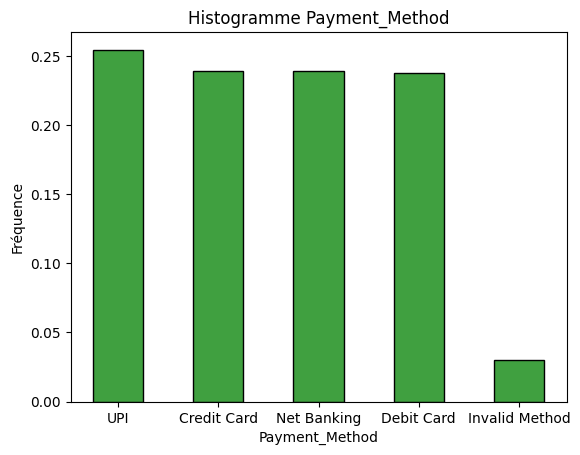

In [13]:
sns.histplot(df_fraudulent['Payment_Method'], stat='density',color = 'green',element='bars',shrink=0.5)
plt.title('Histogramme Payment_Method')
plt.xlabel('Payment_Method')
plt.ylabel('Fréquence')
plt.show()

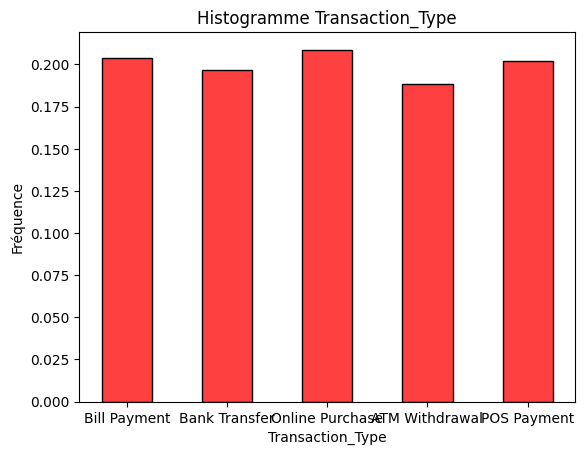

In [14]:
sns.histplot(df_fraudulent['Transaction_Type'], stat='density',color = 'red',shrink=0.5)
plt.title('Histogramme Transaction_Type')
plt.xlabel('Transaction_Type')
plt.ylabel('Fréquence')
plt.show()

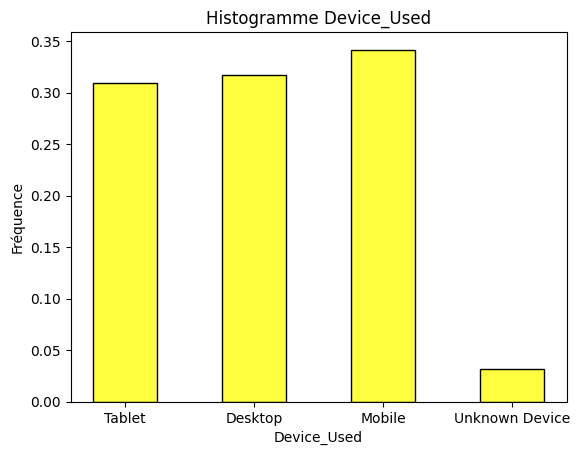

In [15]:
sns.histplot(df_fraudulent['Device_Used'], stat='density',color = 'yellow',shrink=0.5)
plt.title('Histogramme Device_Used')
plt.xlabel('Device_Used')
plt.ylabel('Fréquence')
plt.show()

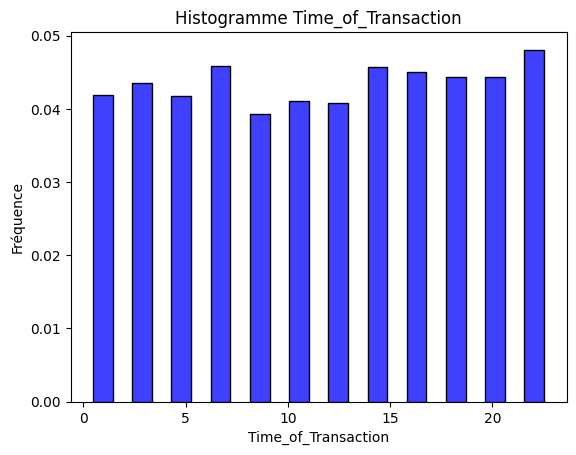

In [16]:
sns.histplot(df_fraudulent['Time_of_Transaction'], bins=12, stat='density',color = 'blue',element='bars',shrink=0.5)
plt.title('Histogramme Time_of_Transaction')
plt.xlabel('Time_of_Transaction')
plt.ylabel('Fréquence')
plt.show()

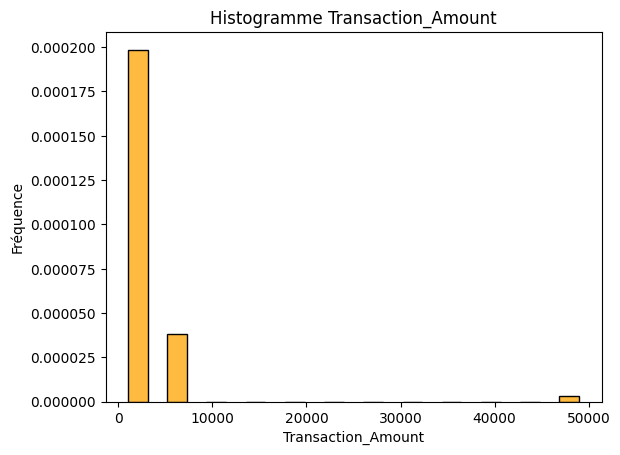

In [17]:
sns.histplot(df_fraudulent['Transaction_Amount'], bins=12, stat='density',color = 'orange',element='bars',shrink=0.5)
plt.title('Histogramme Transaction_Amount')
plt.xlabel('Transaction_Amount')
plt.ylabel('Fréquence')
plt.show()

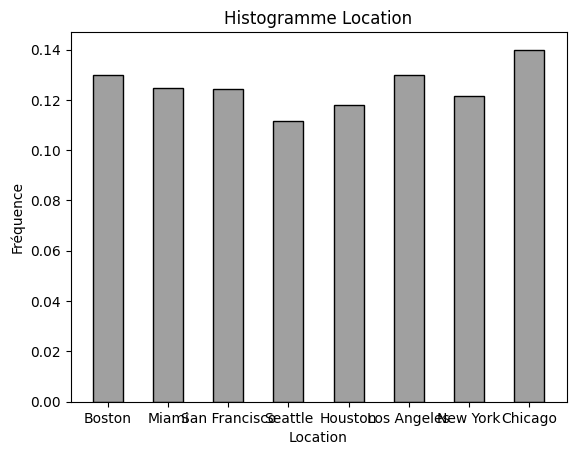

In [18]:
sns.histplot(df_fraudulent['Location'], stat='density',color = 'grey',element='bars',shrink=0.5)
plt.title('Histogramme Location')
plt.xlabel('Location')
plt.ylabel('Fréquence')
plt.show()

In [19]:
data.columns

Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Time_of_Transaction', 'Device_Used', 'Location',
       'Previous_Fraudulent_Transactions', 'Account_Age',
       'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent'],
      dtype='object')

La fraude financière est une problématique majeure dans le monde numérique actuel.
Identifier les transactions frauduleuses est essentiel pour garantir la sécurité, la fiabilité et la confiance des utilisateurs.

Ce jeu de données a été conçu pour permettre l’analyse approfondie des schémas de transactions et la détection des activités frauduleuses.
Il regroupe de nombreux attributs décrivant :
- les détails des transactions,
- le comportement des utilisateurs,
- la localisation,
- et les informations sur les appareils.

Ces données permettent de construire des modèles de détection de fraude performants à l’aide de techniques d’analyse et d’apprentissage automatique.

Caractéristiques Clés du Jeu de Données: Variables du jeu de données et leurs rôles

- Transaction_ID → Identifiant unique de chaque transaction. Sert uniquement à distinguer les enregistrements (clé technique, non utilisée pour la détection).
- User_ID → Identifiant unique de l’utilisateur. Permet de regrouper les transactions par utilisateur et d’analyser les comportements individuels.
- Transaction_Amount → Montant de la transaction. Les montants anormalement élevés ou incohérents peuvent signaler une fraude potentielle.
- Transaction_Type → Type de transaction (achat, virement, retrait, paiement, facture, etc.). Certains types de transactions présentent un risque plus élevé de fraude.
- Time_of_Transaction → Heure ou moment de la transaction. Les opérations réalisées à des heures inhabituelles peuvent être suspectes.
- Device_Used → Type d’appareil utilisé (mobile, ordinateur, tablette). Un changement d’appareil inhabituel peut indiquer une activité frauduleuse.
- Location → Ville ou région depuis laquelle la transaction a été effectuée. Permet de repérer des transactions venant de lieux inhabituels ou incohérents avec le profil de l’utilisateur.
- Previous_Fraudulent_Transactions → Nombre de transactions frauduleuses antérieures associées à l’utilisateur. Indique le niveau de risque historique d’un compte.
- Account_Age → Ancienneté du compte (en jours, mois ou années). Les comptes récents ont souvent un risque plus élevé de fraude.
- Number_of_Transactions_Last_24H → Nombre de transactions effectuées par l’utilisateur au cours des dernières 24 heures. Une activité anormalement élevée peut indiquer une fraude.
- Payment_Method → Mode de paiement (carte de crédit, carte de débit, UPI, banque en ligne, etc.). Certains modes sont plus vulnérables à la fraude.
- Fraudulent → Variable cible. Indique si la transaction est frauduleuse (1) ou légitime (0). Sert à entraîner et évaluer le modèle de détection de fraude.


Objectif du Jeu de Données

L’objectif principal est de fournir une base solide pour le développement et l’entraînement de modèles de détection de fraude.
L’analyse des attributs permet de :
- Détecter les schémas de transactions anormaux ou suspects.
- Identifier les utilisateurs ayant un historique de fraude.
- Améliorer les stratégies de prévention via des modèles d’apprentissage automatique.
- Renforcer la confiance des clients en limitant les cas de fraude financière.



In [20]:
print("Taille du dataset :", data.shape)
data.info()


Taille du dataset : (51000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        5

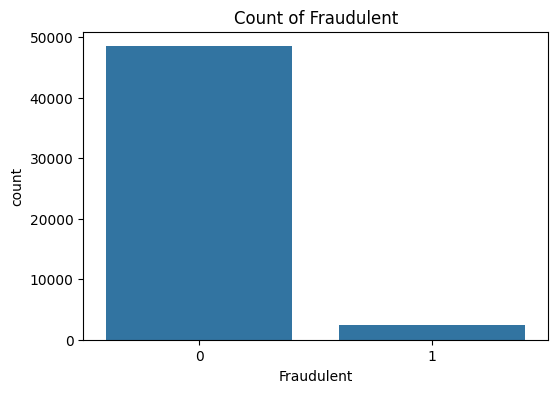

In [21]:
fig , ax = plt.subplots(figsize=(6,4))
sns.countplot(x='Fraudulent', data=data)
plt.title("Count of Fraudulent")
plt.show()

In [22]:

# Récupération des indices des transactions frauduleuses (Class = 1)
indices_fraude = np.array(data[data.Fraudulent == 1].index)
# Comptage du nombre de transactions frauduleuses
nb_transactions_fraude = len(indices_fraude)

# Récupération des indices des transactions normales (Class = 0)
indices_normales = np.array(data[data.Fraudulent == 0].index)
# Comptage du nombre de transactions normales
nb_transactions_normales = len(indices_normales)

# Affichage des résultats
print("Nombre de transactions frauduleuses : {} et nombre de transactions normales : {}".format(
    nb_transactions_fraude, nb_transactions_normales))

Nombre de transactions frauduleuses : 2510 et nombre de transactions normales : 48490


In [23]:
n=len(data)
fraud_0=len(data[data['Fraudulent']==0])
fraud_1=len(data[data['Fraudulent']==1])

print("% of Fraudulent in dataset: ",fraud_1*100/n)
print("% of non Fraudulent in dataset: ",fraud_0*100/n)

% of Fraudulent in dataset:  4.921568627450981
% of non Fraudulent in dataset:  95.07843137254902


In [24]:
print("Nombre total de lignes :", len(data))
print("Nombre de variables :", data.shape[1])
print("Pourcentage de valeurs manquantes :", (data.isnull().mean().mean()*100).round(5), "%")

Nombre total de lignes : 51000
Nombre de variables : 12
Pourcentage de valeurs manquantes : 2.05245 %


In [25]:
print(data.isnull().sum())

Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64


In [26]:

cols_with_missing = ["Transaction_Amount", "Time_of_Transaction", "Device_Used", "Location"]
missing_all = data[data[cols_with_missing].isnull().all(axis=1)]
print("Nombre d'identifiants avec toutes ces valeurs manquantes :", missing_all["User_ID"].nunique())
print("Identifiants concernés :")
print(missing_all["User_ID"].unique())


Nombre d'identifiants avec toutes ces valeurs manquantes : 1
Identifiants concernés :
[1913]


# Gestion des NA par variables

Transaction_Amount

In [27]:
# Séparation des colonnes numériques et catégorielles
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.drop('Fraudulent')
categorical_cols = data.select_dtypes(include=['object', 'category']).columns

# Création d'une copie de sécurité
data_clean = data.copy()

# Remplacement des valeurs manquantes pour les variables numériques
for col in numeric_cols:
    for fraud_value in [0, 1]:
        mean_value = data_clean.loc[data_clean['Fraudulent'] == fraud_value, col].mean()
        data_clean.loc[
            (data_clean['Fraudulent'] == fraud_value) & (data_clean[col].isna()),
            col
        ] = mean_value

# Remplacement des valeurs manquantes pour les variables catégorielles
for col in categorical_cols:
    for fraud_value in [0, 1]:
        mode_series = data_clean.loc[data_clean['Fraudulent'] == fraud_value, col].mode()
        if not mode_series.empty:
            mode_value = mode_series.iloc[0]
            data_clean.loc[
                (data_clean['Fraudulent'] == fraud_value) & (data_clean[col].isna()),
                col
            ] = mode_value

# Vérification du remplissage
print("Pourcentage de valeurs manquantes après traitement :")
print((data_clean.isnull().mean() * 100).round(3))

Pourcentage de valeurs manquantes après traitement :
Transaction_ID                      0.0
User_ID                             0.0
Transaction_Amount                  0.0
Transaction_Type                    0.0
Time_of_Transaction                 0.0
Device_Used                         0.0
Location                            0.0
Previous_Fraudulent_Transactions    0.0
Account_Age                         0.0
Number_of_Transactions_Last_24H     0.0
Payment_Method                      0.0
Fraudulent                          0.0
dtype: float64


/tmp/ipykernel_11274/4014421459.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3002.9993194473086' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_clean.loc[
/tmp/ipykernel_11274/4014421459.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.9953598680140234' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_clean.loc[
/tmp/ipykernel_11274/4014421459.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '59.98537842854197' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_clean.loc[
/tmp/ipykernel_11274/4014421459.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise a

In [21]:
(data["Transaction_Amount"].isnull().mean().mean()*100).round(5), "%"
# Remplacer les valeurs nulles par 0 car absence de montant = pas de transaction
data["Transaction_Amount"] = data["Transaction_Amount"].fillna(0)


Time_of_Transaction

In [22]:
(data["Time_of_Transaction"].isnull().mean().mean()*100).round(5), "%"
# Remplacer les valeurs manquantes dans 'Time_of_Transaction' par la moyenne
data["Time_of_Transaction"] = data["Time_of_Transaction"].fillna(data["Time_of_Transaction"].mean())


Device_Used

In [23]:
(data["Device_Used"].isnull().mean().mean()*100).round(5), "%"
# Remplacer les valeurs manquantes dans 'Device_Used' par le mode (valeur la plus fréquente)
data["Device_Used"] = data["Device_Used"].fillna(data["Device_Used"].mode()[0])


Location

In [24]:
(data["Location"].isnull().mean().mean()*100).round(5), "%"
# Remplacer les valeurs manquantes dans 'Device_Used' par le mode (valeur la plus fréquente)
data["Location"] = data["Location"].fillna(data["Location"].mode()[0])


Payment_Method

In [25]:
(data["Payment_Method"].isnull().mean().mean()*100).round(5), "%"
# Remplacer les valeurs manquantes dans 'Device_Used' par le mode (valeur la plus fréquente)
data["Payment_Method"] = data["Payment_Method"].fillna(data["Payment_Method"].mode()[0])


In [26]:
print(data.isnull().sum())

Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64


Detection des valeurs extremes et anormales

Variables numériques : ['User_ID', 'Transaction_Amount', 'Time_of_Transaction', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Fraudulent']


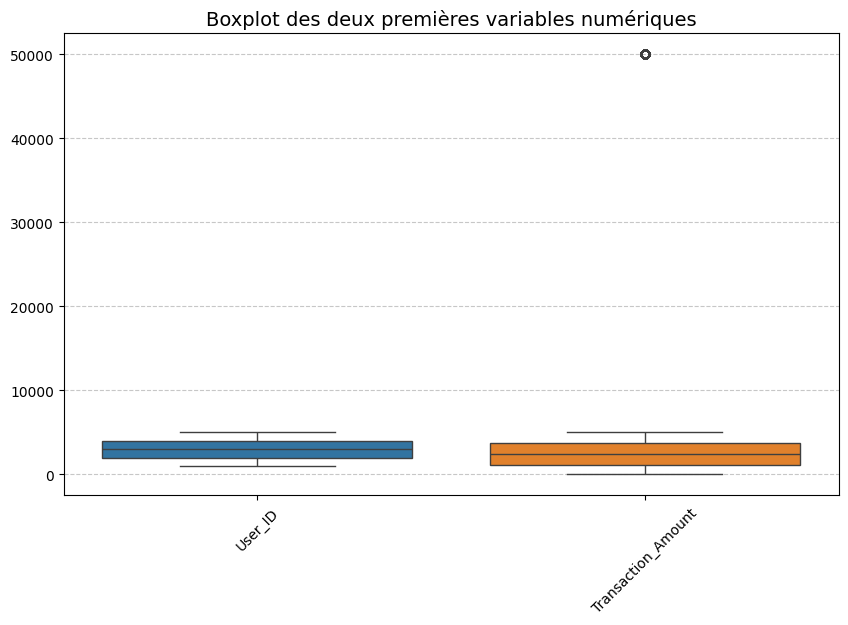

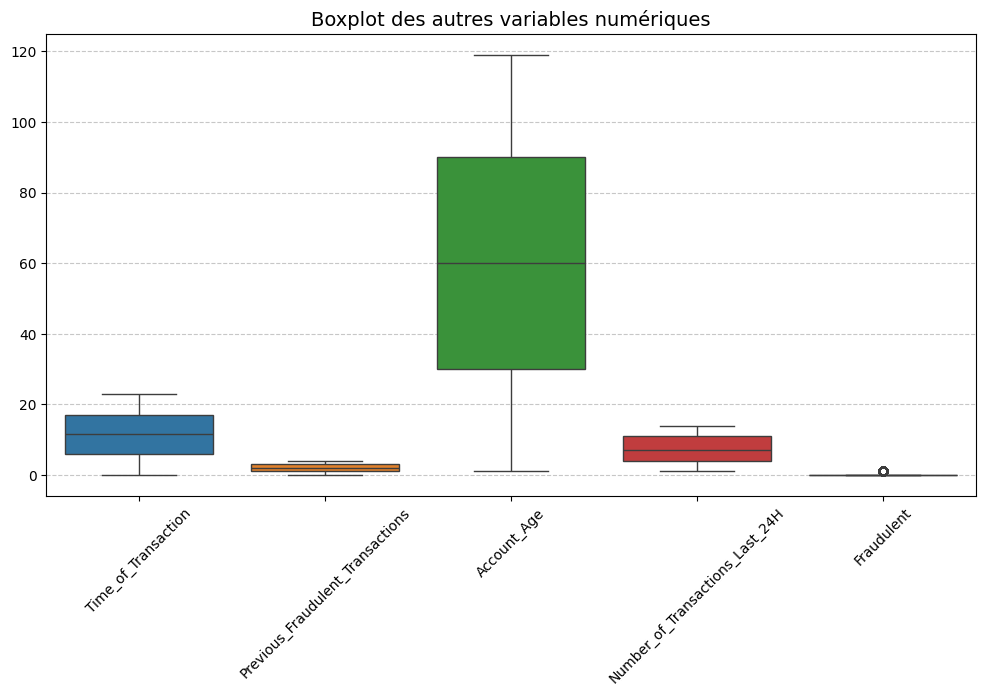

In [27]:

# Sélectionner uniquement les variables numériques
num_cols = data.select_dtypes(include=["int64", "float64"]).columns
print("Variables numériques :", list(num_cols))

plt.figure(figsize=(10, 6))
sns.boxplot(data=data[num_cols[:2]])
plt.title("Boxplot des deux premières variables numériques", fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=data[num_cols[2:]])
plt.title("Boxplot des autres variables numériques", fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()



In [ ]:
# Pour visualiser la distribution réelle des données
sns.pairplot(
    data,
    hue='Fraudulent',
    vars=num_cols
)


<Axes: title={'center': 'Correlation with Fraudulent'}>

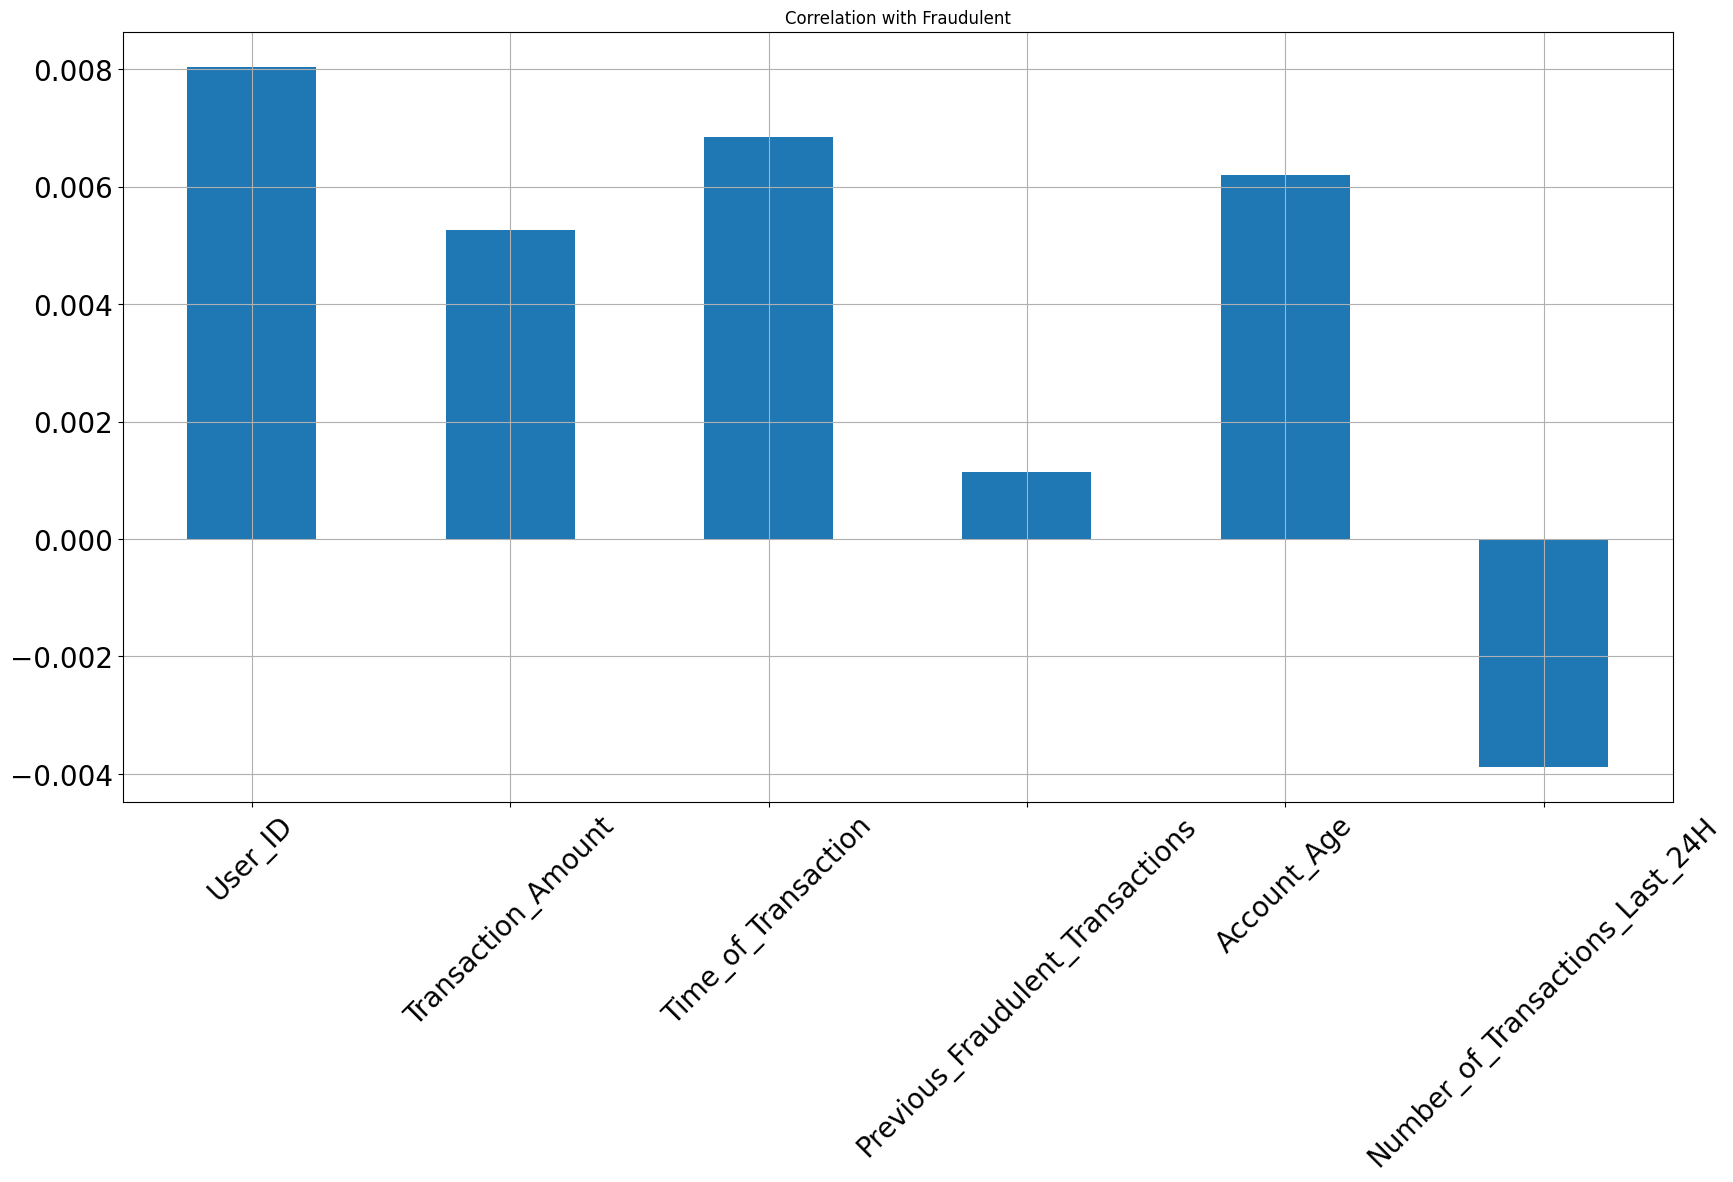

In [37]:
data_num = data.select_dtypes(include=["int64", "float64"])
# Retirer la colonne 'Fraudulent' du dataset numérique (si elle y est)
data_numm = data_num.drop(columns=["Fraudulent"], errors="ignore")
data_numm.corrwith(data["Fraudulent"]).plot.bar(
        figsize = (20, 10), title = "Correlation with Fraudulent", fontsize = 20,
        rot = 45, grid = True)

In [45]:
# Sélectionner les colonnes numériques
numerical_cols = data.select_dtypes(include=np.number).columns

# Remplacer les valeurs manquantes par la moyenne pour les colonnes numériques
for col in numerical_cols:
    if data[col].isnull().any():
        data[col] = data[col].fillna(data[col].mean())

print("Nombre de valeurs manquantes après imputation :")
print(data.isnull().sum())

Nombre de valeurs manquantes après imputation :
Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64


Forme du dataset chargé : (51000, 12)
Fraudulent
0    48490
1     2510
Name: count, dtype: int64
imblearn non disponible. Utilisation d'une implémentation manuelle simple de SMOTE. Erreur : No module named 'imblearn'
Après SMOTE manuel, nouvelle forme : (79592, 11) [38792 40800]


/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Précision : 1.0
Rappel : 0.02390438247011952
AUC : 0.5711465336837841
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9698
           1       1.00      0.02      0.05       502

    accuracy                           0.95     10200
   macro avg       0.98      0.51      0.51     10200
weighted avg       0.95      0.95      0.93     10200

Matrice de confusion :
 [[9698    0]
 [ 490   12]]


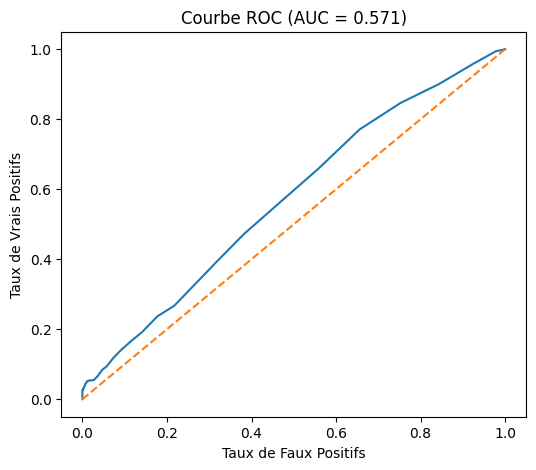

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, roc_curve, auc, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Charger les données
df = pd.read_csv('Fraud Detection Dataset.csv')  # changer le nom du fichier si nécessaire
print('Forme du dataset chargé :', df.shape)
print(df['Fraudulent'].value_counts())

# Basic preprocessing: separate X and y
y = df['Fraudulent']
X = df.drop(columns=['Fraudulent'])

# Imputer les valeurs manquantes conditionnellement sur Fraudulent
for col in X.columns:
    if X[col].isnull().any():
        if X[col].dtype in ['int64', 'float64']:
            # Remplissage conditionnel par la moyenne du groupe
            X[col] = X.groupby(y)[col].transform(lambda x: x.fillna(x.mean()))
        else:
            # Remplissage conditionnel par le mode du groupe
            X[col] = X.groupby(y)[col].transform(lambda x: x.fillna(x.mode()[0]))

# Encode categorical cols (simple)
for col in X.select_dtypes(include=['object','category']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE on training set
try:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(sampling_strategy=0.25, random_state=42)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    print('Après SMOTE, comptes :', np.bincount(y_res.astype(int)))
except Exception as e:
    print('imblearn non disponible. Utilisation d\'une implémentation manuelle simple de SMOTE. Erreur :', e)
    # Simple manual SMOTE (vector interpolation)
    from sklearn.neighbors import NearestNeighbors
    X_train_np = X_train.values
    y_train_np = y_train.values
    minority_idx = np.where(y_train_np==1)[0]
    X_min = X_train_np[minority_idx]

    # Impute missing values in X_min before fitting NearestNeighbors
    # This is a safeguard, ideally all NaNs should be handled before splitting
    for i in range(X_min.shape[1]):
        if np.isnan(X_min[:, i]).any():
            # Replace NaN with mean of the column for numerical data
            if np.issubdtype(X_min[:, i].dtype, np.number):
                mean_val = np.nanmean(X_min[:, i])
                X_min[:, i][np.isnan(X_min[:, i])] = mean_val
            # For non-numerical data (which should be handled by LabelEncoder),
            # this might indicate an issue with encoding or data type.
            # As a fallback, we can use a placeholder or the mode if applicable,
            # but mean imputation is more appropriate for numerical data in SMOTE context.
            # Since LabelEncoder should have handled non-numerical, we focus on numerical here.


    # SMOTE manuel 80-20
    n_majority = np.sum(y_train_np==0)
    target_ratio = 0.2
    n_samples_needed = int((target_ratio * n_majority)/(1-target_ratio)) - len(minority_idx)
    
    neigh = NearestNeighbors(n_neighbors=5).fit(X_min)
    synthetic = []
    rng = np.random.RandomState(42)
    for i in range(n_samples_needed):
        idx = rng.randint(0, X_min.shape[0])
        nn = neigh.kneighbors([X_min[idx]], return_distance=False)[0]
        nn_choice = rng.choice(nn[1:]) if len(nn)>1 else nn[0]
        diff = X_min[nn_choice] - X_min[idx]
        gap = rng.rand()
        synthetic.append(X_min[idx] + gap * diff)
    X_res = np.vstack([X_train_np, np.array(synthetic)])
    y_res = np.hstack([y_train_np, np.ones(len(synthetic))])
    print('Après SMOTE manuel, nouvelle forme :', X_res.shape, np.bincount(y_res.astype(int)))


# Entraîner le classificateur
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_res, y_res)
y_pred = clf.predict(X_test)
y_score = clf.predict_proba(X_test)[:,1]

# Métriques
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

print('Précision :', prec)
print('Rappel :', rec)
print('AUC :', roc_auc)
print(classification_report(y_test, y_pred))
print('Matrice de confusion :\n', confusion_matrix(y_test, y_pred))

# Tracé de la courbe ROC
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC (AUC = %.3f)' % roc_auc)
plt.show()

Forme du dataset chargé : (51000, 12)
Fraudulent
0    48490
1     2510
Name: count, dtype: int64
imblearn non disponible, SMOTE manuel.
Après SMOTE manuel 80-20, nouvelles formes : (48490, 11) [38792  9698]
[LightGBM] [Info] Number of positive: 9698, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000720 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2803
[LightGBM] [Info] Number of data points in the train set: 48490, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200000 -> initscore=-1.386294
[LightGBM] [Info] Start training from score -1.386294
Seuil optimal (Youden) : 0.06255559874842076
Précision : 0.08541114058355438
Rappel : 0.3207171314741036
AUC : 0.6098435706544825
              precision    recall  f1-score   support

           0       0.96      0.82      0.89      96

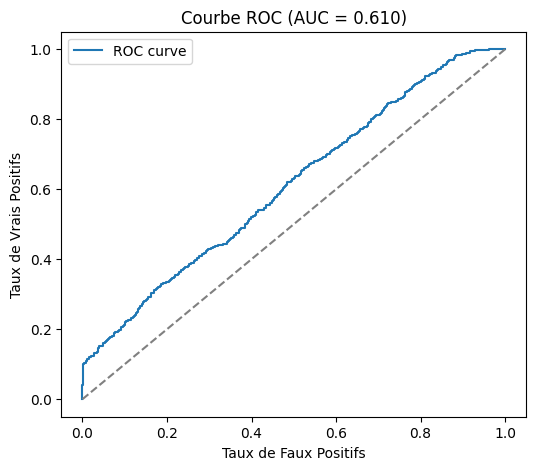

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, roc_curve, auc, classification_report, confusion_matrix
import matplotlib.pyplot as plt
!pip install lightgbm
# Charger LightGBM
try:
    import lightgbm as lgb
except ImportError:
    raise ImportError("Installez lightgbm via `pip install lightgbm`")

# Charger les données
df = pd.read_csv('Fraud Detection Dataset.csv')
print('Forme du dataset chargé :', df.shape)
print(df['Fraudulent'].value_counts())

# Séparer X et y
y = df['Fraudulent']
X = df.drop(columns=['Fraudulent'])

# Imputation conditionnelle des NA
for col in X.columns:
    if X[col].isnull().any():
        if X[col].dtype in ['int64', 'float64']:
            X[col] = X.groupby(y)[col].transform(lambda x: x.fillna(x.mean()))
        else:
            X[col] = X.groupby(y)[col].transform(lambda x: x.fillna(x.mode()[0]))

# Encodage des colonnes catégorielles
for col in X.select_dtypes(include=['object','category']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------
# SMOTE pour la minorité
# ------------------------
try:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(sampling_strategy=0.25, random_state=42)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    print('Après SMOTE, comptes :', np.bincount(y_res.astype(int)))
except Exception as e:
    print('imblearn non disponible, SMOTE manuel.')
    # Version manuelle (comme avant)
    from sklearn.neighbors import NearestNeighbors
    X_train_np = X_train.values
    y_train_np = y_train.values
    minority_idx = np.where(y_train_np==1)[0]
    X_min = X_train_np[minority_idx]

    # Impute NA dans la minorité
    for i in range(X_min.shape[1]):
        if np.isnan(X_min[:, i]).any():
            if np.issubdtype(X_min[:, i].dtype, np.number):
                mean_val = np.nanmean(X_min[:, i])
                X_min[:, i][np.isnan(X_min[:, i])] = mean_val

    # SMOTE manuel 80-20
    n_majority = np.sum(y_train_np==0)
    target_ratio = 0.2
    n_samples_needed = int((target_ratio * n_majority)/(1-target_ratio)) - len(minority_idx)

    neigh = NearestNeighbors(n_neighbors=5).fit(X_min)
    synthetic = []
    rng = np.random.RandomState(42)
    for i in range(n_samples_needed):
        idx = rng.randint(0, X_min.shape[0])
        nn = neigh.kneighbors([X_min[idx]], return_distance=False)[0]
        nn_choice = rng.choice(nn[1:]) if len(nn) > 1 else nn[0]
        diff = X_min[nn_choice] - X_min[idx]
        gap = rng.rand()
        synthetic.append(X_min[idx] + gap * diff)
    X_res = np.vstack([X_train_np, np.array(synthetic)])
    y_res = np.hstack([y_train_np, np.ones(len(synthetic))])
    print('Après SMOTE manuel 80-20, nouvelles formes :', X_res.shape, np.bincount(y_res.astype(int)))

# ------------------------
# Modèle Gradient Boosting LightGBM
# ------------------------
clf = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)
clf.fit(X_res, y_res)

# Prédictions probabilistes
y_score = clf.predict_proba(X_test)[:,1]

# ------------------------
# Seuil optimal : indice de Youden
# ------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_score)
youden_idx = np.argmax(tpr - fpr)  # indice de Youden
optimal_threshold = thresholds[youden_idx]
print("Seuil optimal (Youden) :", optimal_threshold)

# Convertir probabilités en classes selon le seuil
y_pred = (y_score >= optimal_threshold).astype(int)

# ------------------------
# Métriques
# ------------------------
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
roc_auc = auc(fpr, tpr)

print('Précision :', prec)
print('Rappel :', rec)
print('AUC :', roc_auc)
print(classification_report(y_test, y_pred))
print('Matrice de confusion :\n', confusion_matrix(y_test, y_pred))

# Courbe ROC
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title(f'Courbe ROC (AUC = {roc_auc:.3f})')
plt.legend()
plt.show()